In [124]:
import pandas as pd
import requests
import json
import plotly.express as px
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Import and clean the country prices dataset

In [125]:
prices_df = pd.read_csv(r'C:/Users/npste/Farmers-Market/datasets/apri_ap_crpouta$defaultview_linear.csv')
prices_df = prices_df.drop(['DATAFLOW','LAST UPDATE','freq','OBS_FLAG','CONF_STATUS'],axis=1)
prices_df.drop(prices_df[prices_df['currency'] == 'National currency'].index, inplace=True)


### Note: Half the data for Luxembourg and Ireland are missing; substituted with median for the null values (possible outside influence/biases)

In [126]:
prices_df[prices_df["OBS_VALUE"].isnull()]["geo"].value_counts()
prices_df['OBS_VALUE'] = prices_df.groupby('geo')['OBS_VALUE'].transform(lambda x: x.fillna(x.median()))

prices_df.head()

,currency,prod_veg,geo,TIME_PERIOD,OBS_VALUE
0,Euro,Soft wheat - prices per 100 kg,Austria,2015,13.72
1,Euro,Soft wheat - prices per 100 kg,Austria,2016,11.55
2,Euro,Soft wheat - prices per 100 kg,Austria,2017,14.46
3,Euro,Soft wheat - prices per 100 kg,Austria,2018,15.41
4,Euro,Soft wheat - prices per 100 kg,Austria,2019,14.63


In [127]:
prices_df["prod_veg"] = prices_df["prod_veg"].str.replace(r"\s-\sprices.*", "", regex=True)
prices_df["TIME_PERIOD"] = prices_df["TIME_PERIOD"].astype(int)
prices_df = prices_df.rename(columns={"TIME_PERIOD": "year"})
prices_df = prices_df.rename(columns={"OBS_VALUE": "selling_price"})
prices_df.head()

,currency,prod_veg,geo,year,selling_price
0,Euro,Soft wheat,Austria,2015,13.72
1,Euro,Soft wheat,Austria,2016,11.55
2,Euro,Soft wheat,Austria,2017,14.46
3,Euro,Soft wheat,Austria,2018,15.41
4,Euro,Soft wheat,Austria,2019,14.63


In [128]:
fig = px.line(
    prices_df,
    x="year",
    y="selling_price",
    color="geo",
    markers=True,
    title="crop price by country",
    labels={
        "year": "Year",
        "selling_price": "price",
        "geo": "Country/area",
    },
)

fig.show()

In [129]:
# lat, lon of each capital city
eu_countries = {
    "Austria": (48.21, 16.37),
    "Belgium": (50.85, 4.35),
    "Bulgaria": (42.70, 23.32),
    "Croatia": (45.81, 15.98),
    "Cyprus": (35.17, 33.36),
    "Czechia": (50.08, 14.43),
    "Denmark": (55.68, 12.57),
    "Estonia": (59.44, 24.75),
    "Finland": (60.17, 24.94),
    "France": (48.85, 2.35),
    "Germany": (52.52, 13.41),
    "Greece": (37.98, 23.72),
    "Hungary": (47.50, 19.04),
    "Ireland": (53.35, -6.26),
    "Italy": (41.90, 12.50),
    "Latvia": (56.95, 24.10),
    "Lithuania": (54.68, 25.28),
    "Luxembourg": (49.61, 6.13),
    "Malta": (35.90, 14.51),
    "Netherlands": (52.37, 4.90),
    "Poland": (52.23, 21.01),
    "Portugal": (38.72, -9.14),
    "Romania": (44.43, 26.10),
    "Slovakia": (48.15, 17.11),
    "Slovenia": (46.05, 14.51),
    "Spain": (40.42, -3.70),
    "Sweden": (59.33, 18.07)
}

In [130]:
import requests
import pandas as pd

def get_weather(lat, lon, country, year):
    url = "https://archive-api.open-meteo.com/v1/archive"

    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": f"{year}-01-01",
        "end_date": f"{year}-12-31",
        "daily": "temperature_2m_mean,precipitation_sum",
        "timezone": "auto"
    }

    r = requests.get(url, params=params)
    data = r.json()
    df = pd.DataFrame(data["daily"])
    print(df)

    df["time"] = pd.to_datetime(df["time"])
    df["year"] = df["time"].dt.year

    yearly = df.groupby("year").agg({
        "temperature_2m_mean": "mean",
        "precipitation_sum": "sum"
    }).reset_index()

    yearly["geo"] = country

    return yearly

In [131]:
# all_weather = []

# for country, (lat, lon) in eu_countries.items():
#     for year in range(2015, 2025):
#         df = get_weather(lat, lon, country, year)
#         all_weather.append(df)

# weather_df = pd.concat(all_weather, ignore_index=True)

In [132]:
# weather_df.to_csv(r"C:\Users\npste\Farmers-Market\datasets\weather.csv", index=False)

In [133]:
weather_df = pd.read_csv(r"C:\Users\npste\Farmers-Market\datasets\weather.csv")

In [134]:
merged_df = prices_df.merge(
    weather_df,
    on=["geo", "year"],
    how="left"
)

In [135]:
merged_df.head()

,currency,prod_veg,geo,year,selling_price,temperature_2m_mean,precipitation_sum
0,Euro,Soft wheat,Austria,2015,13.72,11.941370,561.2
1,Euro,Soft wheat,Austria,2016,11.55,11.251913,704.2
2,Euro,Soft wheat,Austria,2017,14.46,11.234795,527.5
3,Euro,Soft wheat,Austria,2018,15.41,12.166027,614.9
4,Euro,Soft wheat,Austria,2019,14.63,12.056712,614.0


In [136]:
merged_df = merged_df[~merged_df["geo"].isin(["United Kingdom", "Kosovo*"])]
merged_df.isna().sum()

currency               0
prod_veg               0
geo                    0
year                   0
selling_price          0
temperature_2m_mean    0
precipitation_sum      0
dtype: int64

## Data Visualizations

<Axes: >

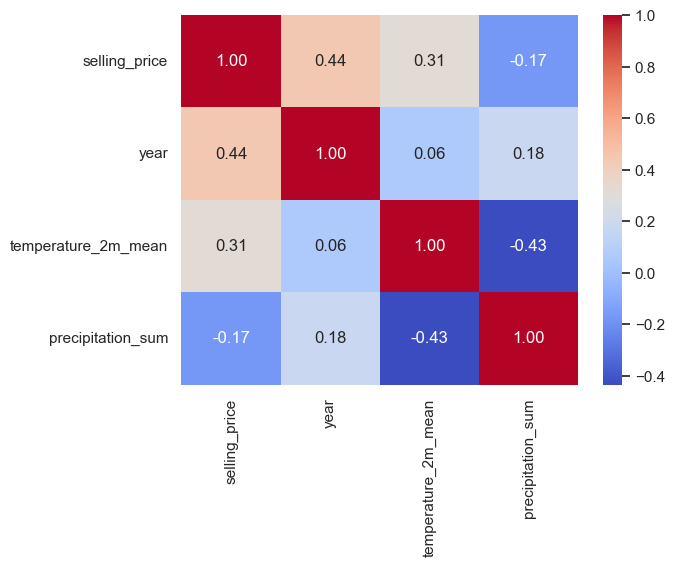

In [137]:
sns.heatmap(merged_df[['selling_price','year',
  'temperature_2m_mean','precipitation_sum']].corr(),
  annot=True, fmt='.2f', cmap='coolwarm')

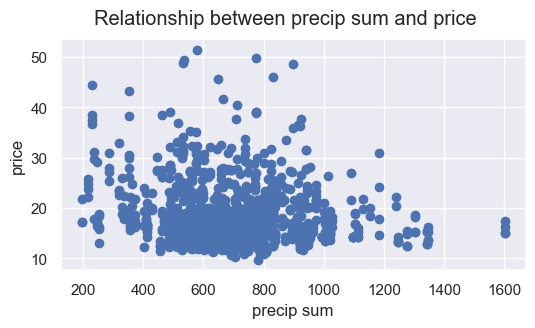

In [138]:
plt.scatter(merged_df['precipitation_sum'], merged_df['selling_price'])
plt.ylabel('price')
plt.xlabel('precip sum')
plt.suptitle('Relationship between precip sum and price')
plt.gcf().set_size_inches(6, 3)

In [139]:
merged_df[['selling_price', 'precipitation_sum']].describe()

,selling_price,precipitation_sum
count,989.000000,989.000000
mean,18.737983,697.579575
std,6.276703,212.781518
min,9.730000,195.900000
25%,14.370000,561.200000
50%,16.810000,680.700000
75%,21.550000,804.200000
max,51.450000,1601.000000


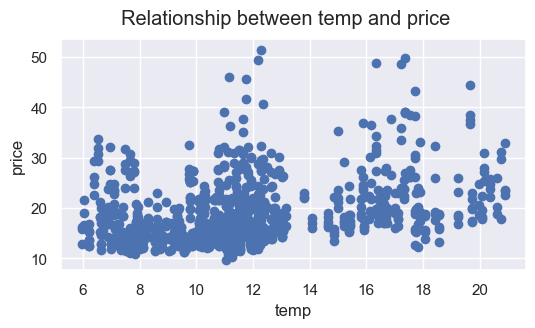

In [140]:
plt.scatter(merged_df['temperature_2m_mean'], merged_df['selling_price'])
plt.ylabel('price')
plt.xlabel('temp')
plt.suptitle('Relationship between temp and price')
plt.gcf().set_size_inches(6, 3)

In [141]:
fig = px.scatter(
    merged_df,
    x="temperature_2m_mean",
    y="selling_price",
    color="geo",
    title="temp vs price by country",
    labels={
        "temperature_2m_mean": "temp",
        "selling_price": "price",
        "geo": "Country/area",
    },
)

fig.show()

In [142]:
avg = merged_df.groupby(['year','prod_veg'])['selling_price'].mean().reset_index()

fig = px.line(avg, x='year', y='selling_price',
    color='prod_veg', markers=True,
    title='Average selling price over time by crop')
fig.show()

In [143]:
# merged_df.to_csv(r"C:\Users\npste\Farmers-Market\datasets\merged_prices_df.csv", index=False)

## Linear Regression Models

### Set up funcs

In [144]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [145]:
def line_of_best_fit(X,y):
    """"
    Finds coefficients of line of best fit

    Args:
        X (array): predictor values
        Y (array): response values
    
    Returns:
        m (array): coefficients for the line of best fit, including intercept
    """
    newX = add_bias_column(X)
    XtXinv = np.linalg.inv(newX.T @ newX)
    m = XtXinv @ (newX.T @ y)


    return m

In [146]:
def linreg_predict(Xnew,Ynew,b):
    """ Returns predicted values, resids, mse, r2

    Args:
        Xnew (array): predictor features
        Ynew (array): response values
        b (array): line of best fit coefficients

    Returns:
        dict (dictionary): contains ypreds, resids, mse, r2
    """
    newX = add_bias_column(Xnew)
    ypreds = newX @ b
    res = ypreds - Ynew
    mse = (res**2).mean()
    r2 = 1 - (mse/Ynew.var())
    dict = {"ypreds": ypreds, "resids": res, "mse": mse, "r2": r2}
    return dict

In [147]:
sns.set()

def get_mse(y_true, y_pred):
    """ gets the MSE

    Args:
        y_true (array): the true y values
        y_pred (array): the predicted y values

    Returns:
        the mean squared error

    """
    
    return np.mean((y_true - y_pred) ** 2)

def show_fit(X, y, slope, intercept):
    """ plots a simple linear regression line through x y points and prints the slope, intercept, and MSE

    Args:
        X (array): the design matrix
        y (array): the response variable
        slope (float): the slope
        intercept (float): the intercept

    Returns:
        A plot (I'm getting lazy with these...)
    """
    
    plt.figure()
    
    # in case this wasn't done before, transform the input data into numpy arrays and flatten them
    x = np.array(X).ravel()
    y = np.array(y).ravel()
    
    # plot the actual data
    plt.scatter(x, y, label='data')
    
    # compute linear predictions 
    # x is a numpy array so each element gets multiplied by slope and intercept is added
    y_pred = slope * x + intercept
    
    # plot the linear fit
    plt.plot(x, y_pred, color='black',
             ls=':',
             label='linear fit')
    
    plt.legend()
    
    plt.xlabel('x')
    plt.ylabel('y')
    
    # print the mean squared error
    y_pred = slope * x + intercept
    mse = get_mse(y_true=y, y_pred=y_pred)
    plt.suptitle(f'y_hat = {slope:.3f} * x + {intercept:.3f}, MSE = {mse:.3f}')

### Simple model - no time series

In [148]:
import numpy as np

# Single-fold cross validation
# note, I'm not scaling anything here, but if I did I would want to have done it AFTER the split, to avoid data leakage
X_new = merged_df.drop(columns=['selling_price','currency','year'])
# add a quadratic term for precipitation?
X_new['precip_squared']=X_new['precipitation_sum']**2
y = merged_df['selling_price']
crossval = train_test_split(X_new, 
                            y,
                            test_size=0.3,
                            random_state=42)
Xtrain, Xtest, ytrain, ytest = crossval

# first demonstrate the usage by fitting the full model
# set up both models using scikit-learn
# modelA = LinearRegression()

Xtrain = pd.get_dummies(Xtrain, columns=['prod_veg', 'geo'], drop_first=True)
Xtest = pd.get_dummies(Xtest, columns=['prod_veg', 'geo'], drop_first=True)

Xtrain = Xtrain.astype(float)
Xtest = Xtest.astype(float)

# align columns in case any categories only appear in one split
Xtrain, Xtest = Xtrain.align(Xtest, join='left', axis=1, fill_value=0)

# Scale numeric cols only
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['temperature_2m_mean', 'precipitation_sum','precip_squared']
Xtrain[numeric_cols] = scaler.fit_transform(Xtrain[numeric_cols])
Xtest[numeric_cols] = scaler.transform(Xtest[numeric_cols])

b = line_of_best_fit(Xtrain, ytrain)
linreg = linreg_predict(Xtest, ytest, b)
resids = linreg['resids']

print(f'MSE: {linreg['mse']}')
print(f'r2: {linreg['r2']}')

MSE: 26.41707956001814
r2: 0.33797165572797316


#### Checking assumptions

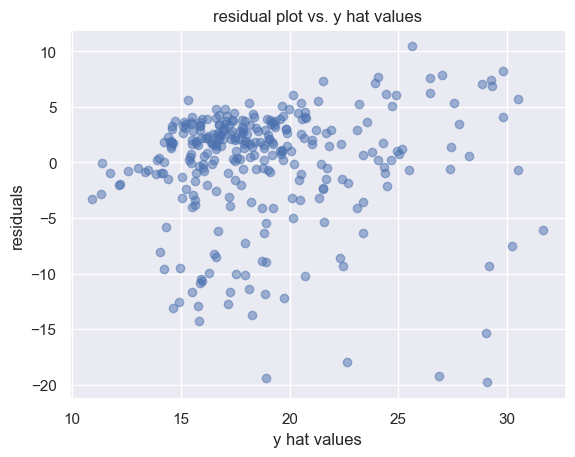

In [149]:
# predicted values versus residuals
plt.scatter(linreg['ypreds'], resids, alpha=0.5)
plt.xlabel("y hat values")
plt.ylabel("residuals")
plt.title("residual plot vs. y hat values")

plt.show()

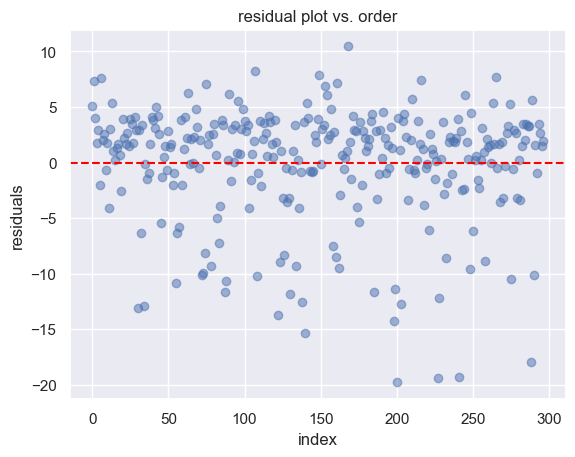

In [150]:
plt.scatter(range(len(ytest)), resids, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("index")
plt.ylabel("residuals")
plt.title("residual plot vs. order")
plt.show()

## Time series model

In [151]:
merged_df = merged_df.sort_values(['geo', 'prod_veg', 'year'])
merged_df['price_lag1'] = merged_df.groupby(['geo', 'prod_veg'])['selling_price'].shift(1)
merged_df['price_lag2'] = merged_df.groupby(['geo', 'prod_veg'])['selling_price'].shift(2)
merged_df = merged_df.dropna(subset=['price_lag1','price_lag2'])

# then rebuild X_new with price_lag1 included
X_new_lag = merged_df.drop(columns=['selling_price', 'currency', 'year'])
X_new_lag['precip_squared']=X_new['precipitation_sum']**2
y = merged_df['selling_price']

In [152]:
crossval = train_test_split(X_new_lag, 
                            y,
                            test_size=0.3,
                            random_state=42)
Xtrainlag, Xtestlag, ytrain, ytest = crossval

# first demonstrate the usage by fitting the full model
# set up both models using scikit-learn
modelAlag = LinearRegression()

Xtrainlag = pd.get_dummies(Xtrainlag, columns=['prod_veg', 'geo'], drop_first=True)
Xtestlag = pd.get_dummies(Xtestlag, columns=['prod_veg', 'geo'], drop_first=True)

# align columns in case any categories only appear in one split
Xtrainlag, Xtestlag = Xtrainlag.align(Xtestlag, join='left', axis=1, fill_value=0)

# Scale numeric cols only
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_cols = ['temperature_2m_mean', 'precipitation_sum','precip_squared','price_lag1','price_lag2']
# numeric_cols = ['temperature_2m_mean','price_lag1']
Xtrainlag[numeric_cols] = scaler.fit_transform(Xtrainlag[numeric_cols])
Xtestlag[numeric_cols] = scaler.transform(Xtestlag[numeric_cols])

# Fit
modelAlag.fit(Xtrainlag, ytrain)

# Predict
predAlag = modelAlag.predict(Xtestlag)

resAlag = predAlag - ytest

MSE_Alag = (resAlag**2).mean()

r2_Alag = 1 - (MSE_Alag)/(ytest.var())

print(f'r2: {r2_Alag}')
print(f'MSE: {MSE_Alag}')

r2: 0.4655654732186889
MSE: 23.2071501763939


In [153]:
print(modelAlag.coef_)
print(modelAlag.intercept_)

[-3.64948752  0.76179926  3.95601302 -0.86965996 -3.51124618  4.72142836
 -0.55225571 -0.86357805  0.52050464  1.77730475 -0.08474577  4.03200942
  8.70766877 -0.38058025 -0.55392141 -3.99625269 -2.50950587  0.86064084
  6.22378289 -0.32832961  6.25345846 10.90655093 -3.01517573 -2.70021128
 -0.12725328  4.39240278 -0.9300229   6.37390673  0.26940422 -1.02000776
  9.20856401  4.26139135 -3.76990597]
17.58329854488158


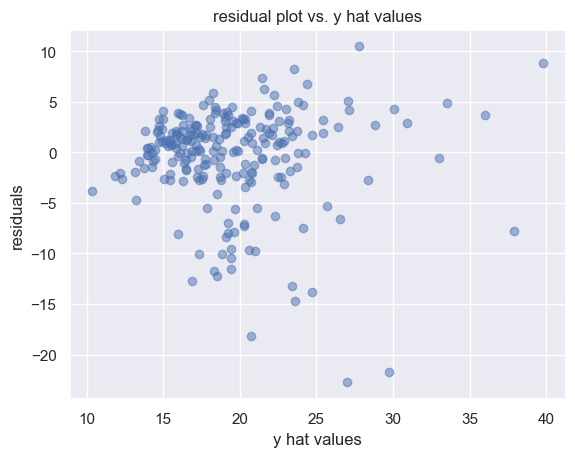

In [154]:
# predicted values versus residuals
plt.scatter(predAlag, resAlag, alpha=0.5)
plt.xlabel("y hat values")
plt.ylabel("residuals")
plt.title("residual plot vs. y hat values")
plt.savefig(r"C:\Users\npste\Belgium-Politics\assets\new_res_vs_yhat.png", dpi=150, bbox_inches='tight')
plt.show()

In [155]:
# fig.write_image(r"C:\Users\npste\Belgium-Politics\assets\res_vs_yhat.png")

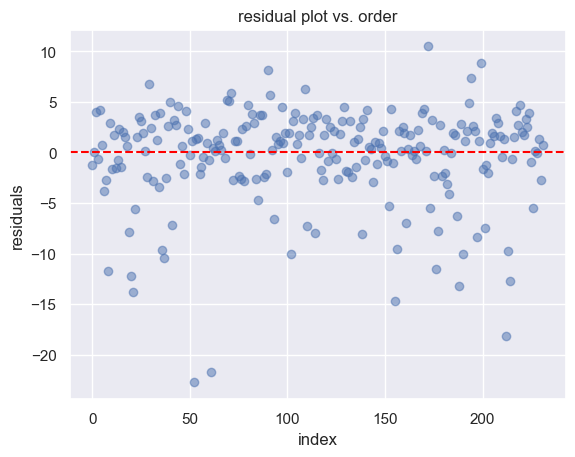

In [156]:
plt.scatter(range(len(ytest)), resAlag, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("index")
plt.ylabel("residuals")
plt.title("residual plot vs. order")
plt.savefig(r"C:\Users\npste\Belgium-Politics\assets\new_res_vs_order.png", dpi=150, bbox_inches='tight')
plt.show()

In [157]:
# fig.write_image(r"C:\Users\npste\Belgium-Politics\assets\res_vs_order.png")

In [158]:
results_df = pd.DataFrame({
    'actual': ytest,
    'predicted': predAlag
})

fig = px.scatter(results_df, x='actual', y='predicted',
    title='Actual vs Predicted Selling Price')

fig.add_shape(type='line',
    x0=ytest.min(), y0=ytest.min(),
    x1=ytest.max(), y1=ytest.max(),
    line=dict(color='red', dash='dash'))

fig.show()

In [159]:
# fig.write_image(r"C:\Users\npste\Belgium-Politics\assets\pred_vs_act.png")

## Fit on full dataset

In [160]:
X_full = pd.get_dummies(X_new_lag, columns=['prod_veg', 'geo'], drop_first=True)
X_full = X_full.astype(float)

scaler_full = StandardScaler()
numeric_cols = ['temperature_2m_mean', 'precipitation_sum', 'price_lag1', 'price_lag2', 'precip_squared']
X_full[numeric_cols] = scaler_full.fit_transform(X_full[numeric_cols])

# fit on everything
final_model = LinearRegression()
final_model.fit(X_full, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [161]:
X_full

,temperature_2m_mean,precipitation_sum,price_lag1,price_lag2,precip_squared,prod_veg_Durum wheat,prod_veg_Feed barley,prod_veg_Rye,prod_veg_Soft wheat,geo_Belgium,...,geo_Lithuania,geo_Luxembourg,geo_Netherlands,geo_Poland,geo_Portugal,geo_Romania,geo_Slovakia,geo_Slovenia,geo_Spain,geo_Sweden
245,-0.185698,-0.868763,-0.155460,1.164028,-0.797771,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
246,0.089224,-0.461920,-0.100178,-0.046472,-0.511120,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
247,0.056951,-0.466110,-0.095572,0.010943,-0.514295,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
248,-0.122729,0.118087,0.174695,0.015728,-0.026625,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
249,-0.312037,-0.328323,0.646126,0.296423,-0.407424,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,-0.907571,-0.473092,-0.765096,0.041245,-0.519577,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
214,-1.409378,-0.198915,-0.666817,-0.679632,-0.302472,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
215,-1.245185,-0.524296,0.025741,-0.577561,-0.557915,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
216,-1.406385,0.269373,1.635056,0.141722,0.114406,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [162]:
# Predict
predAlag = final_model.predict(X_full)

resAlag = predAlag - y

MSE_Alag = (resAlag**2).mean()

r2_Alag = 1 - (MSE_Alag)/(y.var())

print(f'r2: {r2_Alag}')
print(f'MSE: {MSE_Alag}')

print(final_model.coef_)
print(final_model.intercept_)

r2: 0.5245102692783179
MSE: 19.52800176742472
[-4.05561768  0.03238473  4.11676006 -0.80094905 -3.15097735  4.1919153
 -0.3750842  -0.56652415  0.81509433  2.20742962  0.26492839  4.53269217
  9.47985363 -0.4209292  -0.7224791  -3.93099604 -2.36454752  0.41239684
  7.3067975   0.80220496  5.55276409 12.07877268 -3.15999801 -2.58132829
  0.4952049   5.08270567 -0.85023869  7.65509502  1.82805431 -0.01565833
  9.60693273  4.5570161  -4.87394879]
17.163229086853594


In [163]:
beta_vals = [final_model.intercept_] + list(final_model.coef_)
feature_means = list(scaler_full.mean_)
feature_stds = list(scaler_full.scale_)

print("beta_vals:", json.dumps(beta_vals))
print("feature_means:", json.dumps(feature_means))
print("feature_stds:", json.dumps(feature_stds))

beta_vals: [17.163229086853594, -4.055617680655049, 0.032384733797264253, 4.116760058805894, -0.8009490520006273, -3.1509773479122125, 4.191915297758115, -0.3750841997263201, -0.5665241526828857, 0.8150943283928452, 2.207429622564287, 0.2649283873577718, 4.532692168114665, 9.479853634509423, -0.42092919735955603, -0.7224790962825944, -3.9309960356306908, -2.364547518935558, 0.41239683568005264, 7.306797499887298, 0.802204956374758, 5.552764093861776, 12.078772678327395, -3.159998007794143, -2.5813282878838133, 0.49520489645019333, 5.082705673425818, -0.8502386891934479, 7.655095021732872, 1.8280543077882234, -0.015658330744076843, 9.606932730884814, 4.557016104085569, -4.873948787100378]
feature_means: [11.863803408037972, 714.1319948186527, 18.892370466321243, 18.171386010362692, 556134.2881217618]
feature_stds: [3.3872679353610713, 214.8250034285889, 6.512089590267215, 6.270133748497953, 348318.1698134389]


In [164]:
X_)ryeaustria = np.array([1, ]).reshape(-1,1)

SyntaxError: unmatched ')' (341863045.py, line 1)

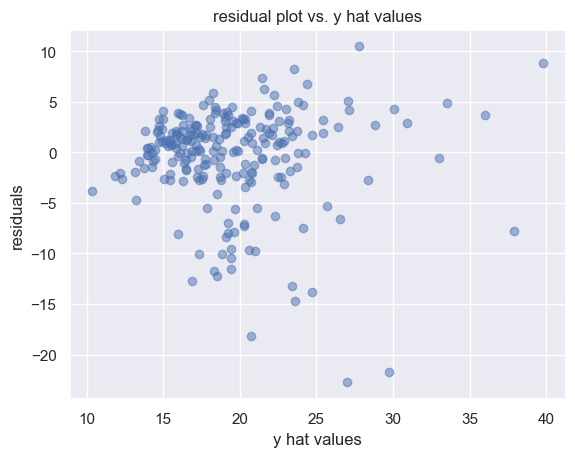

In [ ]:
# predicted values versus residuals
plt.scatter(predAlag, resAlag, alpha=0.5)
plt.xlabel("y hat values")
plt.ylabel("residuals")
plt.title("residual plot vs. y hat values")
plt.show()

In [ ]:
print(merged_df['geo'].unique())
print(merged_df['prod_veg'].unique())

['Austria' 'Belgium' 'Bulgaria' 'Croatia' 'Cyprus' 'Czechia' 'Denmark'
 'Estonia' 'Finland' 'Germany' 'Greece' 'Hungary' 'Ireland' 'Italy'
 'Latvia' 'Lithuania' 'Luxembourg' 'Netherlands' 'Poland' 'Portugal'
 'Romania' 'Slovakia' 'Slovenia' 'Spain' 'Sweden']
['Durum wheat' 'Feed barley' 'Rye' 'Soft wheat' 'Barley']
